
# 12 — Actor-Critic and Proximal Policy Optimization (PPO)

## TD Error, Actor/Critic Updates, PPO Clipping, and Continuous Policies

This notebook follows the lecture progression:

$$
\text{Policy Gradient}
\rightarrow
\text{Actor-Critic}
\rightarrow
\text{One-Step Actor-Critic}
\rightarrow
\text{PPO}
\rightarrow
\text{Continuous-Action Policies}.
$$


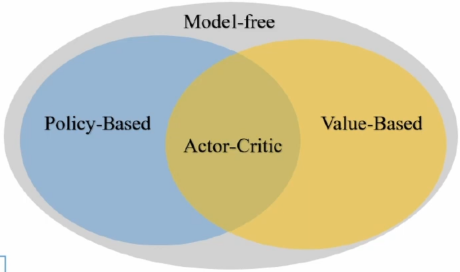


# 1. Actor-Critic concept

Actor-Critic learns a policy and a value function together.

$$
\boxed{
\text{Actor-Critic}
=
\text{Actor}
+
\text{Critic}
}
$$

### Actor

The actor represents the policy:

$$
\pi_{\theta}(a\mid s).
$$

- $\theta$: policy parameters.
- Input: state $s$.
- Output: action distribution.
- Job: select actions and improve the policy.

### Critic

The critic estimates a value function:

$$
\hat V(s;w)
$$

or

$$
\hat Q(s,a;w).
$$

- $w$: critic parameters.
- Job: evaluate the actor's decisions and provide a learning signal.

The common one-step learning signal is the TD error:

$$
\boxed{
\delta_t
=
R_{t+1}
+
\gamma\hat V(S_{t+1};w)
-
\hat V(S_t;w)
}
$$

### How to read the TD error

- $R_{t+1}$: reward observed after taking $A_t$.
- $\hat V(S_t)$: critic's current estimate of the current state.
- $\hat V(S_{t+1})$: critic's estimate of the next state.
- $\gamma$: discount factor.
- $\delta_t$: one-step prediction error.



## 1.1 REINFORCE with baseline versus Actor-Critic

REINFORCE with a baseline can use

$$
G_t-\hat V(S_t)
$$

but still relies on the complete Monte Carlo return $G_t$.

One-step Actor-Critic instead forms a bootstrapped target:

$$
R_{t+1}+\gamma\hat V(S_{t+1}).
$$

Therefore it can update after one transition:

$$
S_t,\;A_t,\;R_{t+1},\;S_{t+1}.
$$



# 2. One-Step Actor-Critic algorithm

The critic update is

$$
\boxed{
w
\leftarrow
w
+
\alpha_w I_t\delta_t
\nabla_w\hat V(S_t;w)
}
$$

The actor update is

$$
\boxed{
\theta
\leftarrow
\theta
+
\alpha_{\theta}I_t\delta_t
\nabla_{\theta}\log\pi_{\theta}(A_t\mid S_t)
}
$$

The discount accumulator is

$$
I_0=1,
\qquad
I_{t+1}=\gamma I_t.
$$

### How to read the actor update

The policy-gradient term

$$
\nabla_{\theta}\log\pi_{\theta}(A_t\mid S_t)
$$

identifies which sampled action probability to change.

The factor

$$
I_t\delta_t
$$

determines the direction and strength of the update.

If $\delta_t>0$, the transition was better than the critic expected.

If $\delta_t<0$, it was worse than expected.


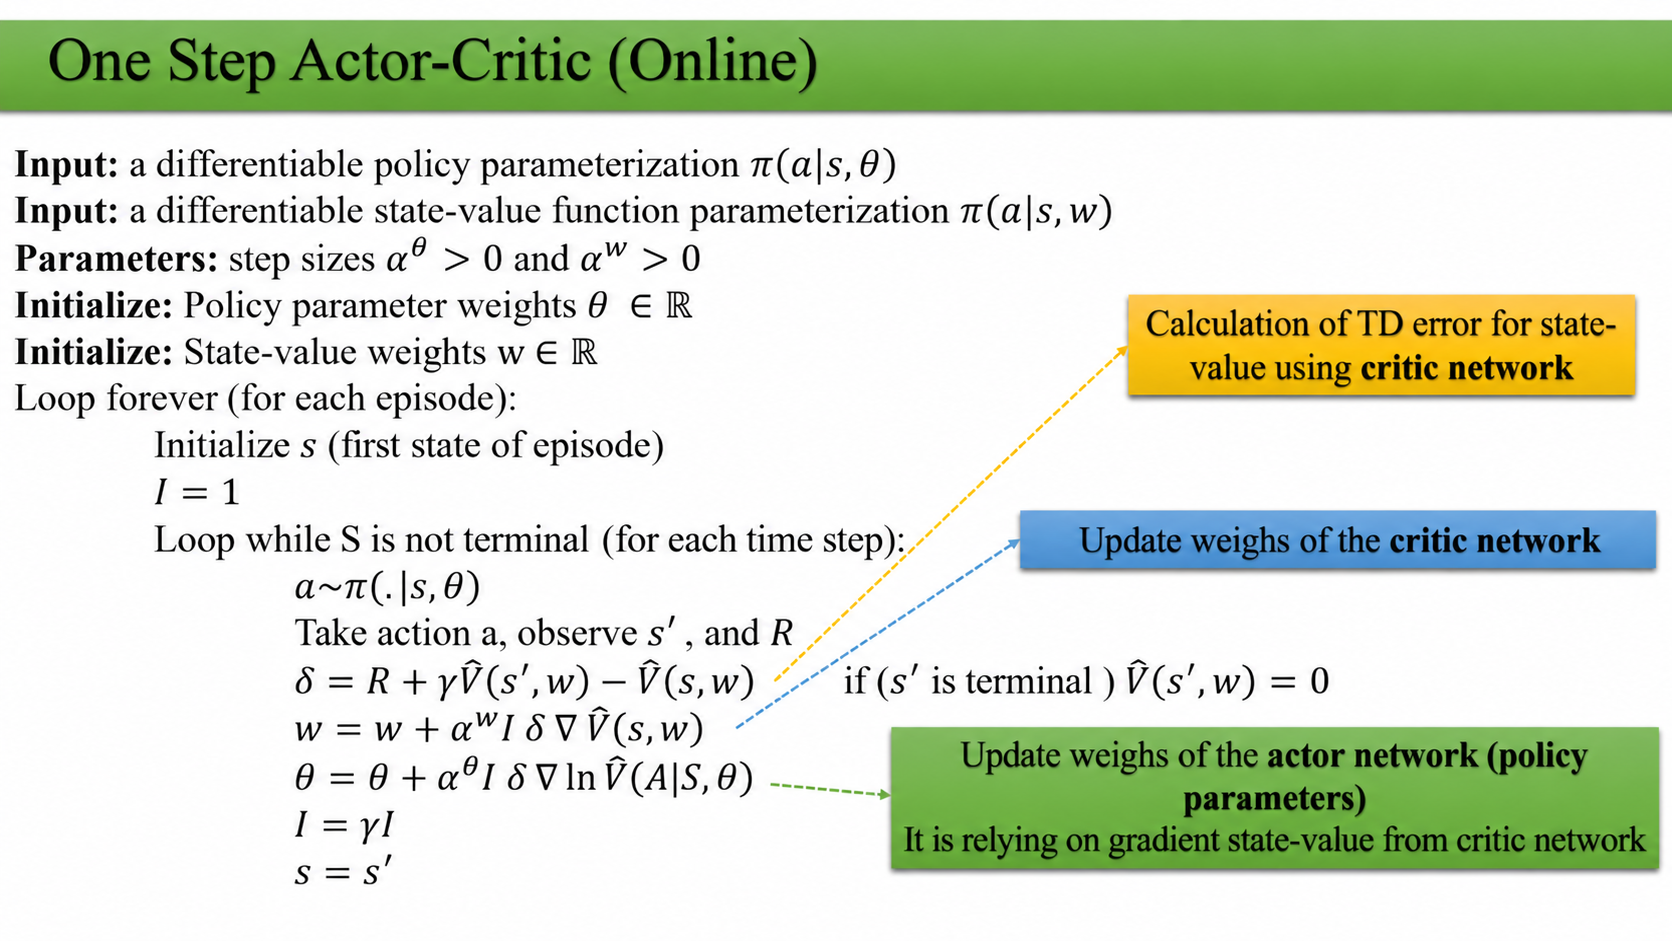


### Algorithm

Input:
    Policy πθ(a|s)
    State-value function V̂(s;w)
    Actor learning rate αθ
    Critic learning rate αw
    Discount factor γ

Initialize:
    Actor parameters θ
    Critic parameters w

For each episode:

    1. Initialize state
       S ← initial state

    2. Initialize discount accumulator
       I ← 1

    3. While S is not terminal:

       a. Select action from current policy
          A ~ πθ(.|S)

       b. Execute action
          Observe reward R and next state S'

       c. Evaluate next state
          If S' is terminal:
              V̂(S';w) = 0

       d. Compute TD target
          y = R + γ V̂(S';w)

       e. Compute TD error
          δ = y - V̂(S;w)

            = R + γV̂(S';w) - V̂(S;w)

       f. Compute critic gradient
          gw = ∇w V̂(S;w)

       g. Update critic parameters
          w ← w + αw I δ gw

       h. Recompute updated state value
          V̂new(S) = V̂(S;wnew)

          For a tabular/simple value function:
          V(S) ← V(S) + αw I δ

       i. Compute actor policy gradient
          gθ = ∇θ log πθ(A|S)

       j. Update actor parameters
          θ ← θ + αθ I δ gθ

       k. Update discount accumulator
          I ← γI

       l. Move to next state
          S ← S'


# 3. Worked One-Step Actor-Critic example

Available actions:

$$
\mathcal A
=
\{\mathrm{Up},\mathrm{Down},\mathrm{Left},\mathrm{Right}\}.
$$

Sample trajectory:

$$
S_0
\xrightarrow{\mathrm{Right},\,2}
S_1
\xrightarrow{\mathrm{Up},\,1}
S_2
\xrightarrow{\mathrm{Left},\,-1}
S_3
\xrightarrow{\mathrm{Right},\,3}
\mathrm{Terminal}.
$$

Use

$$
\gamma=0.9,
\qquad
\alpha_{\theta}=0.1,
\qquad
\alpha_w=0.1.
$$

Initial critic values:

$$
V(S_0)=0.50,
\quad
V(S_1)=0.80,
\quad
V(S_2)=0.40,
\quad
V(S_3)=1.00.
$$

For the manual actor calculation, every state starts with

$$
\mathbf z(s)=
\begin{bmatrix}
0\\0\\0\\0
\end{bmatrix}
$$

so

$$
\boldsymbol{\pi}(s)=
\begin{bmatrix}
0.25\\0.25\\0.25\\0.25
\end{bmatrix}.
$$


## Step 0: state S0, action Right, next state S1

$$
\begin{aligned}\delta_0&=R_{t+1}+\gamma V(S_{t+1})-V(S_t)\\&=2+0.9(0.8000)-0.5000\\&=2.2200\end{aligned}
$$


$$
I_0=1.0000
$$


$$
\begin{aligned}V_{new}(S0)&=V_{old}(S0)+\alpha_w I_t\delta_t\\&=0.5000+0.1(1.0000)(2.2200)\\&=0.7220\end{aligned}
$$


$$
\boldsymbol{\pi}(S0)=\begin{bmatrix}0.2500\\0.2500\\0.2500\\0.2500\end{bmatrix}
$$


$$
\mathbf e_{A_t}=\begin{bmatrix}0.0000\\0.0000\\0.0000\\1.0000\end{bmatrix}
$$


$$
\mathbf g_t=\mathbf e_{A_t}-\boldsymbol{\pi}(S0)=\begin{bmatrix}-0.2500\\-0.2500\\-0.2500\\0.7500\end{bmatrix}
$$


$$
\begin{aligned}\Delta\mathbf z&=\alpha_\theta I_t\delta_t\mathbf g_t\\&=0.1(1.0000)(2.2200)\begin{bmatrix}-0.2500\\-0.2500\\-0.2500\\0.7500\end{bmatrix}\\&=\begin{bmatrix}-0.0555\\-0.0555\\-0.0555\\0.1665\end{bmatrix}\end{aligned}
$$


$$
\mathbf z_{new}(S0)=\begin{bmatrix}-0.0555\\-0.0555\\-0.0555\\0.1665\end{bmatrix}
$$


$$
\boldsymbol{\pi}_{new}(S0)=\begin{bmatrix}0.2354\\0.2354\\0.2354\\0.2939\end{bmatrix}
$$

## Step 1: state S1, action Up, next state S2

$$
\begin{aligned}\delta_1&=R_{t+1}+\gamma V(S_{t+1})-V(S_t)\\&=1+0.9(0.4000)-0.8000\\&=0.5600\end{aligned}
$$


$$
I_1=0.9000
$$


$$
\begin{aligned}V_{new}(S1)&=V_{old}(S1)+\alpha_w I_t\delta_t\\&=0.8000+0.1(0.9000)(0.5600)\\&=0.8504\end{aligned}
$$


$$
\boldsymbol{\pi}(S1)=\begin{bmatrix}0.2500\\0.2500\\0.2500\\0.2500\end{bmatrix}
$$


$$
\mathbf e_{A_t}=\begin{bmatrix}1.0000\\0.0000\\0.0000\\0.0000\end{bmatrix}
$$


$$
\mathbf g_t=\mathbf e_{A_t}-\boldsymbol{\pi}(S1)=\begin{bmatrix}0.7500\\-0.2500\\-0.2500\\-0.2500\end{bmatrix}
$$


$$
\begin{aligned}\Delta\mathbf z&=\alpha_\theta I_t\delta_t\mathbf g_t\\&=0.1(0.9000)(0.5600)\begin{bmatrix}0.7500\\-0.2500\\-0.2500\\-0.2500\end{bmatrix}\\&=\begin{bmatrix}0.0378\\-0.0126\\-0.0126\\-0.0126\end{bmatrix}\end{aligned}
$$


$$
\mathbf z_{new}(S1)=\begin{bmatrix}0.0378\\-0.0126\\-0.0126\\-0.0126\end{bmatrix}
$$


$$
\boldsymbol{\pi}_{new}(S1)=\begin{bmatrix}0.2596\\0.2468\\0.2468\\0.2468\end{bmatrix}
$$

## Step 2: state S2, action Left, next state S3

$$
\begin{aligned}\delta_2&=R_{t+1}+\gamma V(S_{t+1})-V(S_t)\\&=-1+0.9(1.0000)-0.4000\\&=-0.5000\end{aligned}
$$


$$
I_2=0.8100
$$


$$
\begin{aligned}V_{new}(S2)&=V_{old}(S2)+\alpha_w I_t\delta_t\\&=0.4000+0.1(0.8100)(-0.5000)\\&=0.3595\end{aligned}
$$


$$
\boldsymbol{\pi}(S2)=\begin{bmatrix}0.2500\\0.2500\\0.2500\\0.2500\end{bmatrix}
$$


$$
\mathbf e_{A_t}=\begin{bmatrix}0.0000\\0.0000\\1.0000\\0.0000\end{bmatrix}
$$


$$
\mathbf g_t=\mathbf e_{A_t}-\boldsymbol{\pi}(S2)=\begin{bmatrix}-0.2500\\-0.2500\\0.7500\\-0.2500\end{bmatrix}
$$


$$
\begin{aligned}\Delta\mathbf z&=\alpha_\theta I_t\delta_t\mathbf g_t\\&=0.1(0.8100)(-0.5000)\begin{bmatrix}-0.2500\\-0.2500\\0.7500\\-0.2500\end{bmatrix}\\&=\begin{bmatrix}0.0101\\0.0101\\-0.0304\\0.0101\end{bmatrix}\end{aligned}
$$


$$
\mathbf z_{new}(S2)=\begin{bmatrix}0.0101\\0.0101\\-0.0304\\0.0101\end{bmatrix}
$$


$$
\boldsymbol{\pi}_{new}(S2)=\begin{bmatrix}0.2525\\0.2525\\0.2425\\0.2525\end{bmatrix}
$$

## Step 3: state S3, action Right, next state Terminal

$$
\begin{aligned}\delta_3&=R_{t+1}+\gamma V(S_{t+1})-V(S_t)\\&=3+0.9(0.0000)-1.0000\\&=2.0000\end{aligned}
$$


$$
I_3=0.7290
$$


$$
\begin{aligned}V_{new}(S3)&=V_{old}(S3)+\alpha_w I_t\delta_t\\&=1.0000+0.1(0.7290)(2.0000)\\&=1.1458\end{aligned}
$$


$$
\boldsymbol{\pi}(S3)=\begin{bmatrix}0.2500\\0.2500\\0.2500\\0.2500\end{bmatrix}
$$


$$
\mathbf e_{A_t}=\begin{bmatrix}0.0000\\0.0000\\0.0000\\1.0000\end{bmatrix}
$$


$$
\mathbf g_t=\mathbf e_{A_t}-\boldsymbol{\pi}(S3)=\begin{bmatrix}-0.2500\\-0.2500\\-0.2500\\0.7500\end{bmatrix}
$$


$$
\begin{aligned}\Delta\mathbf z&=\alpha_\theta I_t\delta_t\mathbf g_t\\&=0.1(0.7290)(2.0000)\begin{bmatrix}-0.2500\\-0.2500\\-0.2500\\0.7500\end{bmatrix}\\&=\begin{bmatrix}-0.0365\\-0.0365\\-0.0365\\0.1094\end{bmatrix}\end{aligned}
$$


$$
\mathbf z_{new}(S3)=\begin{bmatrix}-0.0365\\-0.0365\\-0.0365\\0.1094\end{bmatrix}
$$


$$
\boldsymbol{\pi}_{new}(S3)=\begin{bmatrix}0.2406\\0.2406\\0.2406\\0.2783\end{bmatrix}
$$


In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ACTIONS = ["Up", "Down", "Left", "Right"]
ACTION_TO_INDEX = {a:i for i,a in enumerate(ACTIONS)}
gamma = 0.90
alpha_actor = 0.10
alpha_critic = 0.10

trajectory = [
    ("S0","Right", 2.0,"S1"),
    ("S1","Up",    1.0,"S2"),
    ("S2","Left", -1.0,"S3"),
    ("S3","Right", 3.0,"Terminal"),
]

def softmax(z):
    z = np.asarray(z, dtype=float)
    e = np.exp(z - np.max(z))
    return e/e.sum()

def grad_log_softmax(p, action):
    g = -np.asarray(p, dtype=float).copy()
    g[ACTION_TO_INDEX[action]] += 1.0
    return g

values = {"S0":0.50,"S1":0.80,"S2":0.40,"S3":1.00,"Terminal":0.0}
logits = {s:np.zeros(4) for s in ["S0","S1","S2","S3"]}

rows=[]
I=1.0

for t,(s,a,r,sn) in enumerate(trajectory):
    p = softmax(logits[s])
    delta = r + gamma*values[sn] - values[s]

    old_v = values[s]
    values[s] += alpha_critic*I*delta

    g = grad_log_softmax(p,a)
    logits[s] += alpha_actor*I*delta*g

    rows.append({
        "t":t,
        "State":s,
        "Action":a,
        "Reward":r,
        "TD error":delta,
        "V before":old_v,
        "V after":values[s],
        "P(action) before":p[ACTION_TO_INDEX[a]],
        "P(action) after":softmax(logits[s])[ACTION_TO_INDEX[a]]
    })

    I *= gamma

ac_df = pd.DataFrame(rows)
ac_df


,t,State,Action,Reward,TD error,V before,V after,P(action) before,P(action) after
0,0,S0,Right,2.0,2.22,0.5,0.7220,0.25,0.293880
1,1,S1,Up,1.0,0.56,0.8,0.8504,0.25,0.259569
2,2,S2,Left,-1.0,-0.50,0.4,0.3595,0.25,0.242483
3,3,S3,Right,3.0,2.00,1.0,1.1458,0.25,0.278320


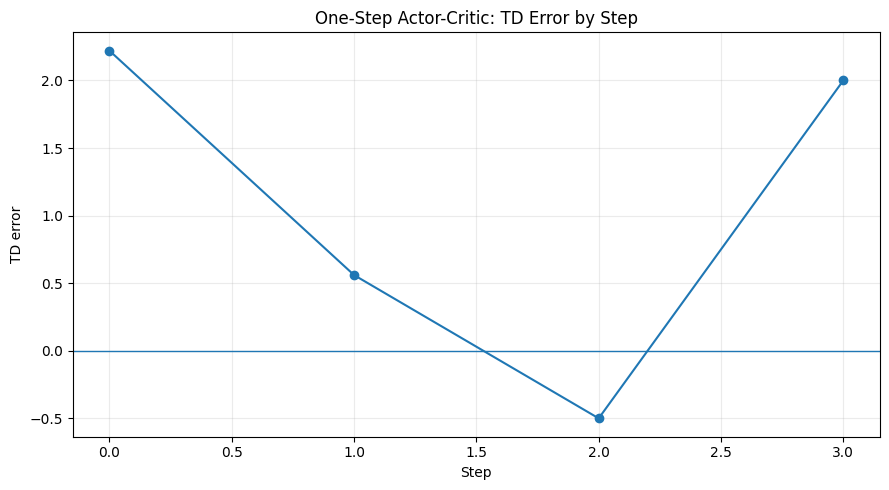

In [8]:

plt.figure(figsize=(9,5))
plt.plot(ac_df["t"], ac_df["TD error"], marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("Step")
plt.ylabel("TD error")
plt.title("One-Step Actor-Critic: TD Error by Step")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


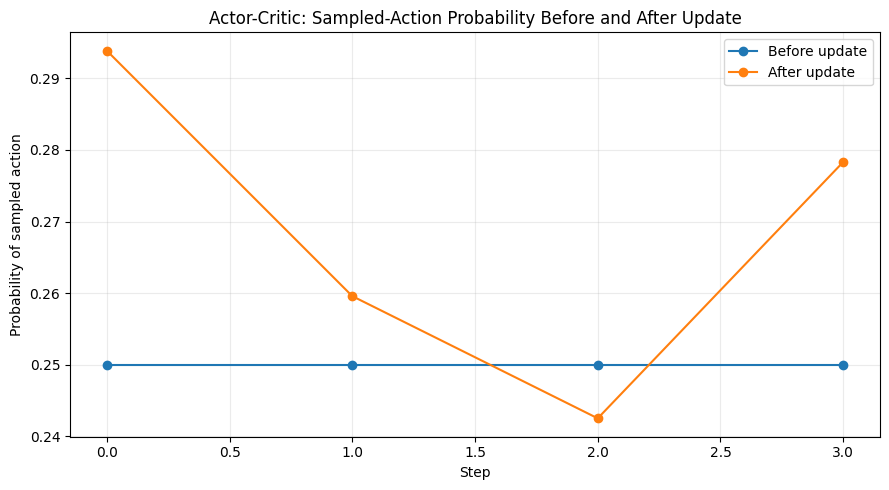

In [9]:

plt.figure(figsize=(9,5))
plt.plot(ac_df["t"], ac_df["P(action) before"], marker="o", label="Before update")
plt.plot(ac_df["t"], ac_df["P(action) after"], marker="o", label="After update")
plt.xlabel("Step")
plt.ylabel("Probability of sampled action")
plt.title("Actor-Critic: Sampled-Action Probability Before and After Update")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()



# 4. Why PPO?

Actor-Critic can still make a large policy update when the gradient signal is large.

PPO limits the incentive for the new policy to move too far from the policy that collected the data.

The old rollout policy is

$$
\pi_{\theta_{\mathrm{old}}}.
$$

The policy currently being optimized is

$$
\pi_{\theta}.
$$

The probability ratio is

$$
\boxed{
r_t(\theta)
=
\frac{
\pi_{\theta}(A_t\mid S_t)
}{
\pi_{\theta_{\mathrm{old}}}(A_t\mid S_t)
}
}
$$

### How to read the ratio

- $r_t=1$: no change.
- $r_t>1$: sampled action became more likely.
- $r_t<1$: sampled action became less likely.



# 5. PPO surrogate objective

Before clipping,

$$
J(\theta)
=
\mathbb E
\left[
r_t(\theta)\hat A_t
\right].
$$

- $\hat A_t>0$: sampled action was better than expected.
- $\hat A_t<0$: sampled action was worse than expected.

Without a constraint, repeatedly maximizing this objective can push the policy ratio too far from $1$.



# 6. PPO clipped surrogate objective

PPO uses the interval

$$
[1-\epsilon,\;1+\epsilon].
$$

For

$$
\epsilon=0.2,
$$

the interval is

$$
[0.8,\;1.2].
$$

The clipping rule is

$$
\operatorname{clip}(r_t,0.8,1.2)
=
\begin{cases}
0.8, & r_t<0.8,\\
r_t, & 0.8\le r_t\le1.2,\\
1.2, & r_t>1.2.
\end{cases}
$$

The PPO objective is

$$
\boxed{
L^{\mathrm{CLIP}}(\theta)
=
\mathbb E
\left[
\min
\left(
r_t(\theta)\hat A_t,\;
\operatorname{clip}
(r_t(\theta),1-\epsilon,1+\epsilon)
\hat A_t
\right)
\right]
}
$$

### How to read it

For every sampled transition:

1. compute the ordinary term $r_t\hat A_t$;
2. compute the clipped term;
3. take the smaller term;
4. average across the batch.

This removes the incentive for certain excessively large probability changes.



# 7. Worked PPO clipping example

Use

$$
\epsilon=0.20,
\qquad
[1-\epsilon,1+\epsilon]=[0.80,1.20].
$$

## Sample 1: state S0, action Right

$$
r_t=\frac{\pi_{new}(A_t\mid S_t)}{\pi_{old}(A_t\mid S_t)}=\frac{0.44}{0.40}=1.1000
$$


$$
\operatorname{clip}(1.1000,0.8,1.2)=1.1000
$$


$$
\hat A_t=2.0000
$$


$$
L_1=r_t\hat A_t=(1.1000)(2.0000)=2.2000
$$


$$
L_2=\operatorname{clip}(r_t,0.8,1.2)\hat A_t=(1.1000)(2.0000)=2.2000
$$


$$
L_t^{\mathrm{CLIP}}=\min(2.2000,2.2000)=2.2000
$$

## Sample 2: state S1, action Up

$$
r_t=\frac{\pi_{new}(A_t\mid S_t)}{\pi_{old}(A_t\mid S_t)}=\frac{0.45}{0.30}=1.5000
$$


$$
\operatorname{clip}(1.5000,0.8,1.2)=1.2000
$$


$$
\hat A_t=1.5000
$$


$$
L_1=r_t\hat A_t=(1.5000)(1.5000)=2.2500
$$


$$
L_2=\operatorname{clip}(r_t,0.8,1.2)\hat A_t=(1.2000)(1.5000)=1.8000
$$


$$
L_t^{\mathrm{CLIP}}=\min(2.2500,1.8000)=1.8000
$$

## Sample 3: state S2, action Left

$$
r_t=\frac{\pi_{new}(A_t\mid S_t)}{\pi_{old}(A_t\mid S_t)}=\frac{0.45}{0.50}=0.9000
$$


$$
\operatorname{clip}(0.9000,0.8,1.2)=0.9000
$$


$$
\hat A_t=-1.0000
$$


$$
L_1=r_t\hat A_t=(0.9000)(-1.0000)=-0.9000
$$


$$
L_2=\operatorname{clip}(r_t,0.8,1.2)\hat A_t=(0.9000)(-1.0000)=-0.9000
$$


$$
L_t^{\mathrm{CLIP}}=\min(-0.9000,-0.9000)=-0.9000
$$

## Sample 4: state S3, action Down

$$
r_t=\frac{\pi_{new}(A_t\mid S_t)}{\pi_{old}(A_t\mid S_t)}=\frac{0.20}{0.40}=0.5000
$$


$$
\operatorname{clip}(0.5000,0.8,1.2)=0.8000
$$


$$
\hat A_t=-2.0000
$$


$$
L_1=r_t\hat A_t=(0.5000)(-2.0000)=-1.0000
$$


$$
L_2=\operatorname{clip}(r_t,0.8,1.2)\hat A_t=(0.8000)(-2.0000)=-1.6000
$$


$$
L_t^{\mathrm{CLIP}}=\min(-1.0000,-1.6000)=-1.6000
$$

## Sample 5: state S4, action Right

$$
r_t=\frac{\pi_{new}(A_t\mid S_t)}{\pi_{old}(A_t\mid S_t)}=\frac{0.30}{0.25}=1.2000
$$


$$
\operatorname{clip}(1.2000,0.8,1.2)=1.2000
$$


$$
\hat A_t=0.8000
$$


$$
L_1=r_t\hat A_t=(1.2000)(0.8000)=0.9600
$$


$$
L_2=\operatorname{clip}(r_t,0.8,1.2)\hat A_t=(1.2000)(0.8000)=0.9600
$$


$$
L_t^{\mathrm{CLIP}}=\min(0.9600,0.9600)=0.9600
$$

## Batch objective

$$
L^{\mathrm{CLIP}}=\frac{1}{5}\sum_{t=1}^5L_t^{\mathrm{CLIP}}=0.4920
$$


In [10]:

epsilon = 0.20

ppo_samples = [
    ("S0","Right",0.40,0.44,  2.0),
    ("S1","Up",   0.30,0.45,  1.5),
    ("S2","Left", 0.50,0.45, -1.0),
    ("S3","Down", 0.40,0.20, -2.0),
    ("S4","Right",0.25,0.30,  0.8),
]

rows=[]

for s,a,p_old,p_new,adv in ppo_samples:
    ratio = p_new/p_old
    clipped_ratio = np.clip(ratio,1-epsilon,1+epsilon)
    term1 = ratio*adv
    term2 = clipped_ratio*adv

    rows.append({
        "State":s,
        "Action":a,
        "pi_old":p_old,
        "pi_new":p_new,
        "Advantage":adv,
        "Ratio":ratio,
        "Clipped ratio":clipped_ratio,
        "Unclipped":term1,
        "Clipped":term2,
        "PPO term":min(term1,term2)
    })

ppo_df = pd.DataFrame(rows)
display(ppo_df)
print("Mean clipped objective =", ppo_df["PPO term"].mean())


,State,Action,pi_old,pi_new,Advantage,Ratio,Clipped ratio,Unclipped,Clipped,PPO term
0,S0,Right,0.40,0.44,2.0,1.1,1.1,2.20,2.20,2.20
1,S1,Up,0.30,0.45,1.5,1.5,1.2,2.25,1.80,1.80
2,S2,Left,0.50,0.45,-1.0,0.9,0.9,-0.90,-0.90,-0.90
3,S3,Down,0.40,0.20,-2.0,0.5,0.8,-1.00,-1.60,-1.60
4,S4,Right,0.25,0.30,0.8,1.2,1.2,0.96,0.96,0.96


Mean clipped objective = 0.4919999999999999


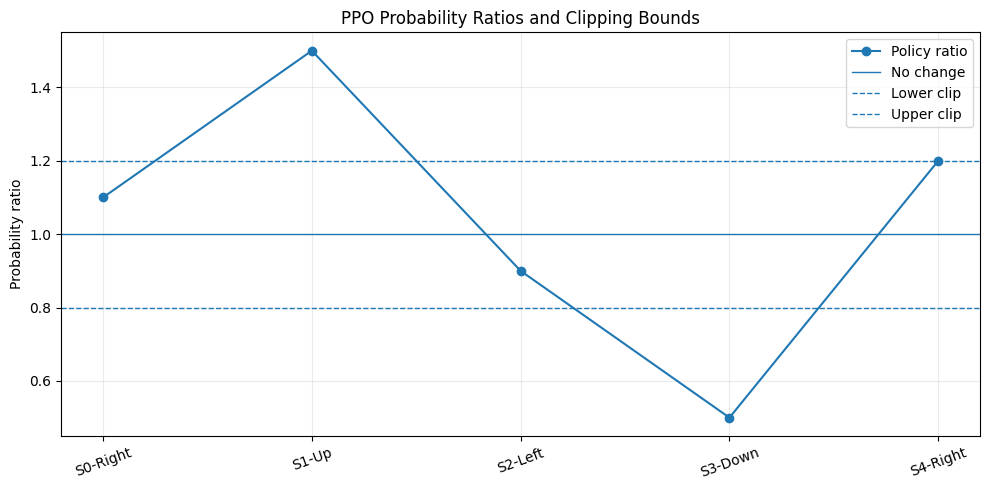

In [11]:

plt.figure(figsize=(10,5))
x = np.arange(len(ppo_df))
plt.plot(x, ppo_df["Ratio"], marker="o", label="Policy ratio")
plt.axhline(1.0, linewidth=1, label="No change")
plt.axhline(0.8, linestyle="--", linewidth=1, label="Lower clip")
plt.axhline(1.2, linestyle="--", linewidth=1, label="Upper clip")
plt.xticks(x, [f"{s}-{a}" for s,a in zip(ppo_df["State"], ppo_df["Action"])], rotation=20)
plt.ylabel("Probability ratio")
plt.title("PPO Probability Ratios and Clipping Bounds")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()



# 8. Why the sign of the advantage matters

For a positive advantage,

$$
\hat A_t>0,
$$

PPO wants to increase the sampled action probability.

Once

$$
r_t>1+\epsilon,
$$

the clipped objective stops rewarding additional increase.

For a negative advantage,

$$
\hat A_t<0,
$$

PPO wants to decrease the sampled action probability.

Once

$$
r_t<1-\epsilon,
$$

the clipped objective stops rewarding additional decrease.



# 9. PPO as an Actor-Critic method

Actor:

$$
\pi_{\theta}(a\mid s)
$$

Critic:

$$
V_{\phi}(s)
$$

A simple one-step advantage estimate is

$$
\hat A_t
=
R_{t+1}
+
\gamma V_{\phi}(S_{t+1})
-
V_{\phi}(S_t).
$$

The actor uses the clipped PPO objective.

The critic can minimize

$$
L_V(\phi)
=
\frac{1}{2}
\left[
V_{\phi}(S_t)
-
V_t^{\mathrm{target}}
\right]^2.
$$

The actor and critic may use separate networks or share lower layers.


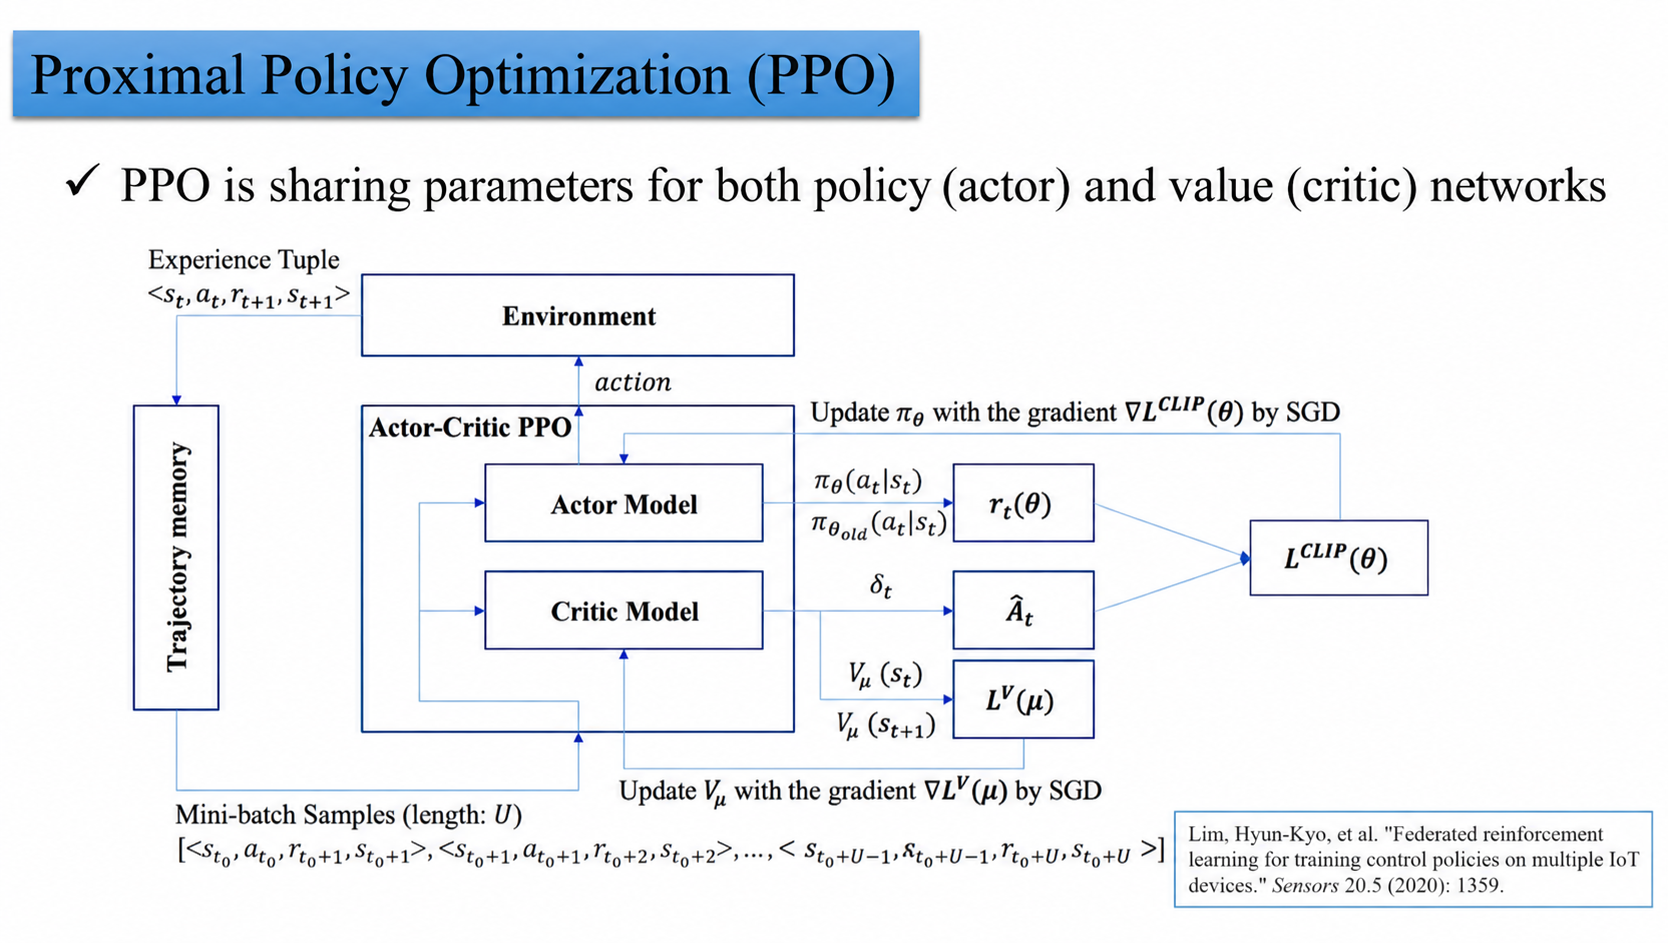

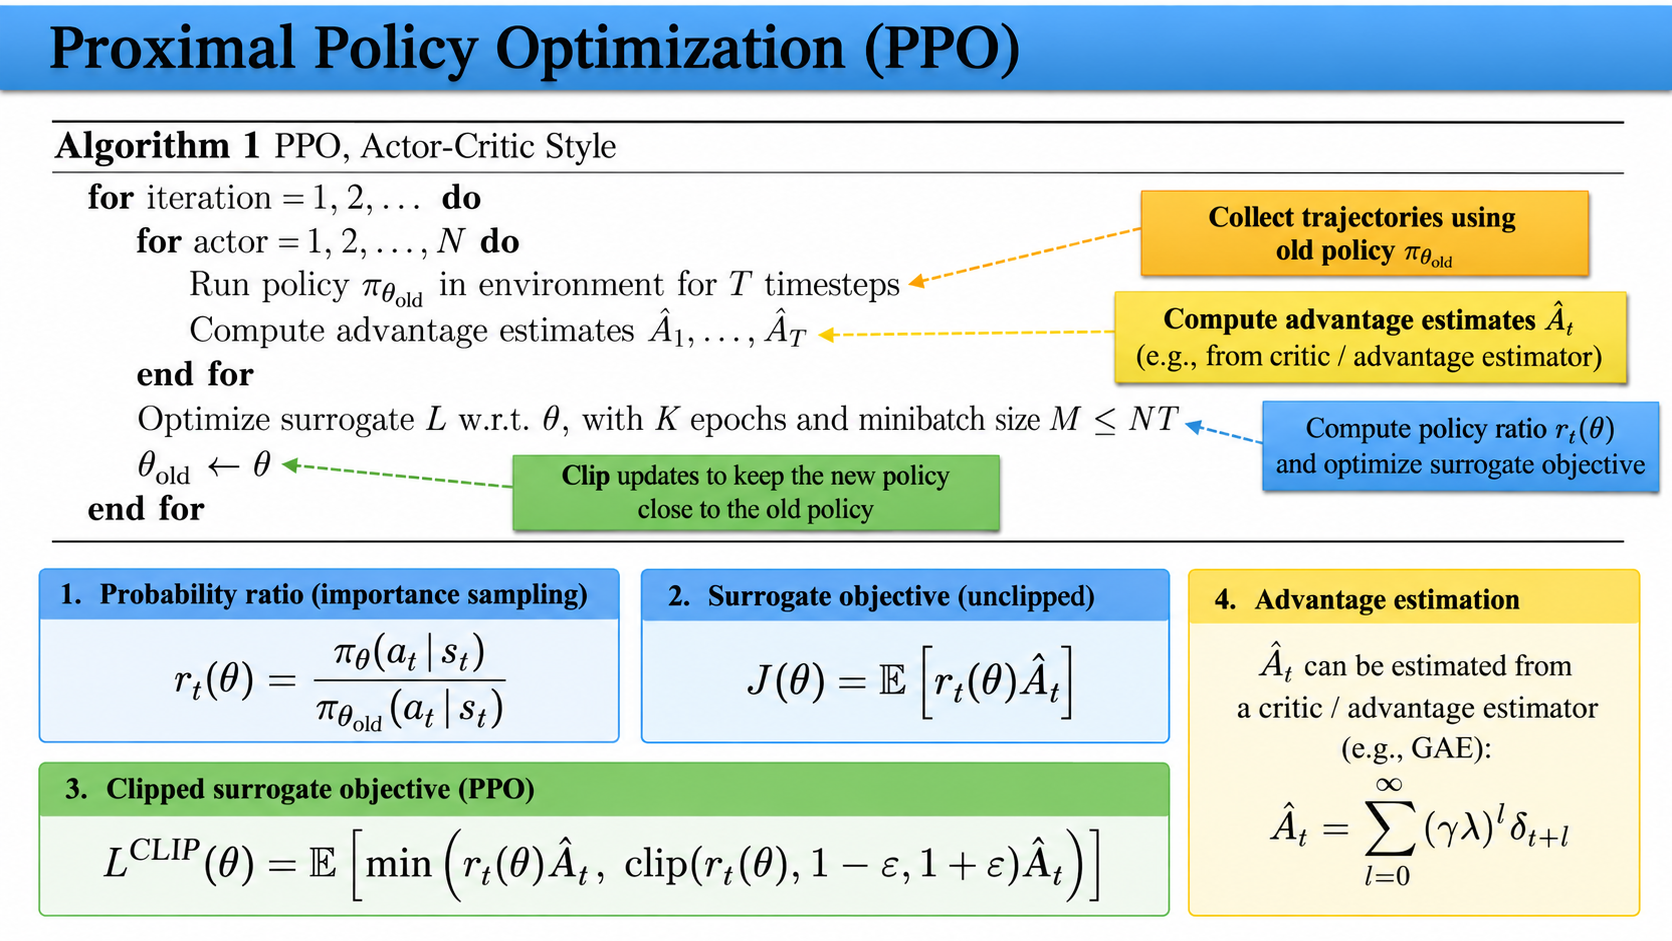


# 10. PPO training loop

```text
Initialize actor parameters θ
Initialize critic parameters φ

For each PPO iteration:

    θ_old ← θ

    Run π_{θ_old} in the environment
    and collect rollout data

    Compute:
        value targets
        advantage estimates

    For K optimization epochs:

        shuffle rollout data
        split it into mini-batches

        for each mini-batch:
            compute r_t
            compute clipped actor objective
            compute critic value loss
            update actor and critic

    Use the updated policy for the next rollout
```

Important:

- rollout data are collected using the old policy;
- the same rollout can be reused for multiple optimization epochs;
- clipping limits the incentive for the new policy to move too far from the old policy.


#11.
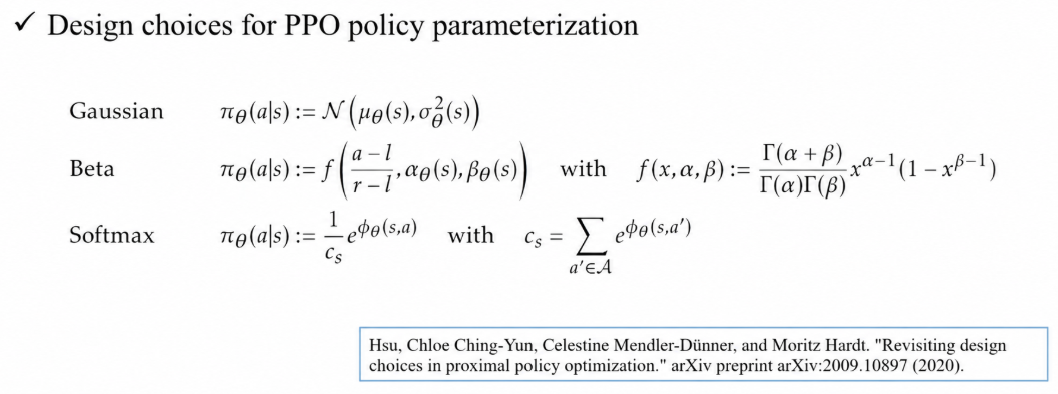


# 12. Policy parameterization for continuous actions

For discrete actions, softmax is common:

$$
\pi_{\theta}(a\mid s)
=
\frac{
e^{z_a(s)}
}{
\sum_{a'}e^{z_{a'}(s)}
}.
$$

For continuous actions, there may be infinitely many possible actions.

The policy network therefore predicts parameters of a probability distribution.

A common Gaussian policy is

$$
\boxed{
\pi_{\theta}(a\mid s)
=
\mathcal N
\left(
\mu_{\theta}(s),
\sigma_{\theta}^2(s)
\right)
}
$$

with density

$$
\pi_{\theta}(a\mid s)
=
\frac{1}
{\sigma_{\theta}(s)\sqrt{2\pi}}
\exp
\left[
-\frac{
(a-\mu_{\theta}(s))^2
}{
2\sigma_{\theta}^2(s)
}
\right].
$$

The network learns

$$
\mu_{\theta}(s)
$$

and

$$
\sigma_{\theta}(s).
$$

For bounded continuous actions, a Beta distribution is another possible parameterization.


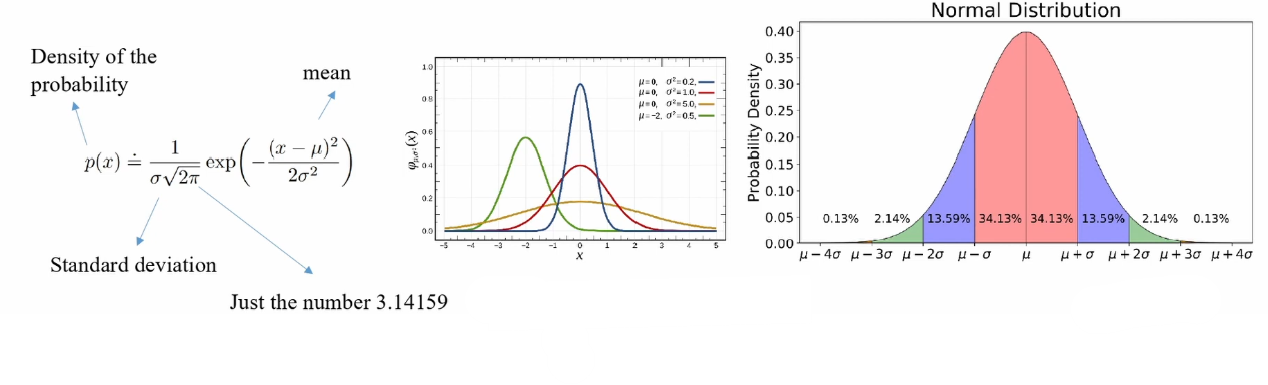


## 12.1 Continuous-action PPO ratio

PPO still uses

$$
r_t(\theta)
=
\frac{
\pi_{\theta}(A_t\mid S_t)
}{
\pi_{\theta_{\mathrm{old}}}(A_t\mid S_t)
}.
$$

For continuous actions, the numerator and denominator are probability densities.

Example:

$$
\mu_{\mathrm{old}}=0,
\qquad
\sigma_{\mathrm{old}}=1,
$$

$$
\mu_{\mathrm{new}}=0.2,
\qquad
\sigma_{\mathrm{new}}=0.9,
$$

and

$$
A_t=0.5.
$$



$$
\pi_{old}(0.5\mid s)=0.352065
$$

$$
\pi_{new}(0.5\mid s)=0.419315
$$

$$
r_t=\frac{0.419315}{0.352065}=1.191014
$$


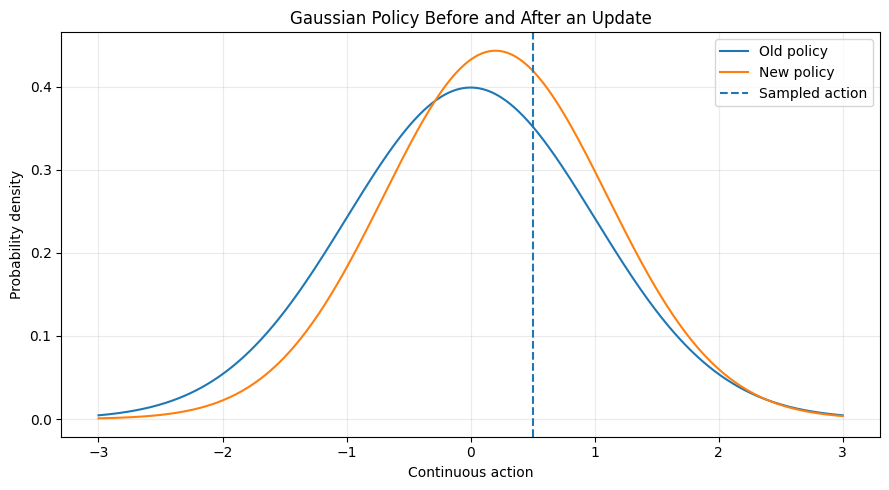

Old density = 0.3520653267642995
New density = 0.4193146974366591
Density ratio = 1.1910138987284642


In [12]:

def normal_pdf(x,mu,sigma):
    return (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-((x-mu)**2)/(2*sigma**2))

mu_old, sigma_old = 0.0, 1.0
mu_new, sigma_new = 0.2, 0.9
a = 0.5

x = np.linspace(-3,3,500)

plt.figure(figsize=(9,5))
plt.plot(x, normal_pdf(x,mu_old,sigma_old), label="Old policy")
plt.plot(x, normal_pdf(x,mu_new,sigma_new), label="New policy")
plt.axvline(a, linestyle="--", label="Sampled action")
plt.xlabel("Continuous action")
plt.ylabel("Probability density")
plt.title("Gaussian Policy Before and After an Update")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

old_density = normal_pdf(a,mu_old,sigma_old)
new_density = normal_pdf(a,mu_new,sigma_new)

print("Old density =", old_density)
print("New density =", new_density)
print("Density ratio =", new_density/old_density)



# 13. Actor-Critic versus PPO

| Feature | One-Step Actor-Critic | PPO |
|---|---|---|
| Actor | Policy | Policy |
| Critic | Value function | Value function |
| Actor learning signal | TD error / advantage | Advantage |
| Policy ratio | Not required | Required |
| Clipping | No | Yes |
| Rollout reuse | Usually limited | Multiple epochs |
| Main goal | Learn actor and critic online | Improve policy while limiting large policy changes |

PPO can be viewed as an Actor-Critic policy-gradient method with an additional mechanism that constrains the effective policy update.



# 14. Final equation map

Actor-Critic TD error:

$$
\boxed{
\delta_t
=
R_{t+1}
+
\gamma V(S_{t+1})
-
V(S_t)
}
$$

Critic update:

$$
\boxed{
w
\leftarrow
w
+
\alpha_w I_t\delta_t
\nabla_wV(S_t;w)
}
$$

Actor update:

$$
\boxed{
\theta
\leftarrow
\theta
+
\alpha_{\theta}I_t\delta_t
\nabla_{\theta}
\log\pi_{\theta}(A_t\mid S_t)
}
$$

PPO ratio:

$$
\boxed{
r_t(\theta)
=
\frac{
\pi_{\theta}(A_t\mid S_t)
}{
\pi_{\theta_{\mathrm{old}}}(A_t\mid S_t)
}
}
$$

PPO clipped objective:

$$
\boxed{
L^{\mathrm{CLIP}}(\theta)
=
\mathbb E
\left[
\min
\left(
r_t(\theta)\hat A_t,\;
\operatorname{clip}
(r_t(\theta),1-\epsilon,1+\epsilon)
\hat A_t
\right)
\right]
}
$$

Continuous Gaussian policy:

$$
\boxed{
\pi_{\theta}(a\mid s)
=
\mathcal N
\left(
\mu_{\theta}(s),
\sigma_{\theta}^2(s)
\right)
}
$$
